# TorchSpin — Real-World Fitting: Bad Initial Conditions and Multi-Parameter Fits

This notebook picks up where `03_spectral_fitting.ipynb` leaves off and demonstrates the two headline capabilities of the new `method='global'` pipeline:

1. **Bad-initial-conditions recovery** — when your starting guess for `g` is off by a few hundredths and `A` is off by tens of MHz, a plain Nelder-Mead simplex traps in a local minimum. The particle-swarm+simplex pipeline escapes.
2. **Multi-parameter stress test** — fitting an anisotropic g-tensor, one hyperfine coupling, and a Gaussian linewidth all at once (5 free parameters) recovers every value to better than 0.05 % relative error in ~80 s.
3. **Bonus: a quick differentiable gradient fit** using `torch.autograd` + Adam, 50 steps.

**Related notebooks:**
- `03_spectral_fitting.ipynb` — basic getting-started with `esfit`.
- `04_benchmarks.ipynb` — measurements producing the manuscript numbers, including the full 200-step Adam run and the MSE-vs-integral-MSE loss study.

**Expected runtime**: ~3 min on a CUDA workstation, ~4 min on CPU.


In [1]:
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchspin import (
    SpinSystem, Experiment, Options,
    pepper, esfit, addnoise, FitOptions,
    differentiable_spectrum,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120


## 1. The loss-landscape slice — why simplex traps

Before running any fit, let's look at the shape of the loss function we're trying to minimise. We'll generate a noisy spectrum, then scan one parameter (`g_x`) across the starting-guess neighbourhood with `A_x` fixed at the true value, and plot the RMSD at each point.

This takes ~10 s.


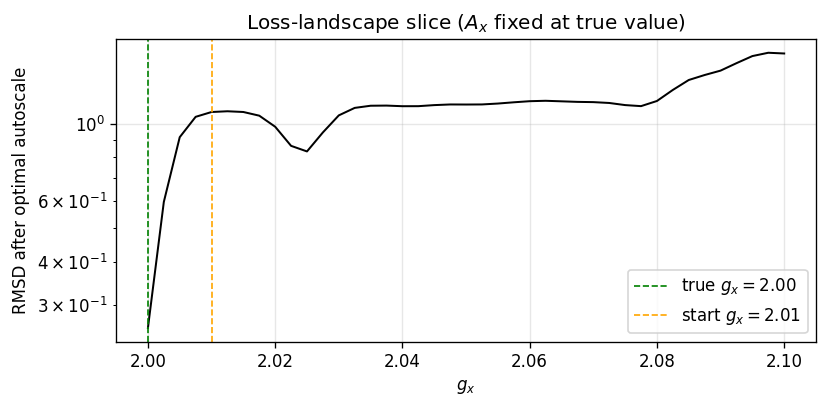

Local maxima at g_x = ['2.013', '2.038', '2.047', '2.062', '2.098']
Local minima at g_x = ['2.025', '2.040', '2.050', '2.078']
Global minimum at g_x = 2.000


In [2]:
# Ground-truth spin system
sys_true = SpinSystem(S=0.5, g=[2.00, 2.10, 2.20], Nucs=['1H'],
                     A=[[120.0, 50.0, 78.0]], lw=[1.0, 0.0])
exp_bench = Experiment(mwFreq=10.0, Range=[300, 380], nPoints=1024, Harmonic=1)
opt_bench = Options(GridSize=31, GridSymmetry='C2h', Verbosity=0)

B, spc_clean = pepper(sys_true, exp_bench, opt_bench)
np.random.seed(42)
spc_data = addnoise(spc_clean.numpy(), 50, 'n')
B_np = B.numpy()

# Forward model: vary g_x and A_x only
def model_2p(params):
    gx, Ax = params
    sys = SpinSystem(S=0.5, g=[gx, 2.10, 2.20], Nucs=['1H'],
                    A=[[Ax, 50.0, 78.0]], lw=[1.0, 0.0])
    _, spc = pepper(sys, exp_bench, opt_bench)
    return spc.numpy()

# Scan g_x with A_x fixed at the true value
gx_scan = np.linspace(2.000, 2.100, 41)
rmsd_scan = np.empty_like(gx_scan)
for i, gx in enumerate(gx_scan):
    sim = model_2p([gx, 120.0])
    scale = (sim @ spc_data) / (sim @ sim + 1e-12)
    rmsd_scan[i] = np.sqrt(np.mean((scale * sim - spc_data) ** 2))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(gx_scan, rmsd_scan, 'k-', lw=1.2)
ax.axvline(2.00, color='green', lw=1.0, ls='--', label='true $g_x = 2.00$')
ax.axvline(2.01, color='orange', lw=1.0, ls='--', label='start $g_x = 2.01$')
ax.set_xlabel(r'$g_x$')
ax.set_ylabel('RMSD after optimal autoscale')
ax.set_title('Loss-landscape slice ($A_x$ fixed at true value)')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find the local minima between start and truth
from scipy.signal import argrelextrema
maxima_idx = argrelextrema(rmsd_scan, np.greater)[0]
minima_idx = argrelextrema(rmsd_scan, np.less)[0]
print(f'Local maxima at g_x = {[f"{gx_scan[i]:.3f}" for i in maxima_idx]}')
print(f'Local minima at g_x = {[f"{gx_scan[i]:.3f}" for i in minima_idx]}')
print(f'Global minimum at g_x = {gx_scan[np.argmin(rmsd_scan)]:.3f}')


**What this plot shows**: the loss is not monotonic between the start point (g_x=2.01) and the truth (g_x=2.00). A local optimizer starting at 2.01 will walk downhill along the local gradient, landing in the nearest basin on the **wrong side** of the peak at g_x≈2.005, never reaching the true minimum at 2.00.

Derivative EPR spectra produce this oscillation because the derivative shape has both positive and negative lobes — as the simulated spectrum slides past the data, these lobes alternately reinforce and cancel, creating the ripple.


## 2. Simplex traps, `method='global'` escapes

Same data, same starting guess. We run `method='simplex'` and `method='global'` side-by-side. Total runtime: ~25 s.


In [3]:
p0 = np.array([2.01, 110.0])       # slightly off in g_x, 10 MHz off in A_x
vary = np.array([0.10, 30.0])      # realistic search bounds
true = np.array([2.00, 120.0])

results = {}
for method in ['simplex', 'global']:
    max_iter = 2000 if method == 'simplex' else 200
    t0 = time.perf_counter()
    res = esfit(spc_data, model_2p, p0, vary,
                options=FitOptions(method=method, max_iter=max_iter,
                                   swarm_size=20, seed=42, verbosity=0))
    elapsed = time.perf_counter() - t0
    rmsd = np.sqrt(np.mean((spc_data - res.fit) ** 2))
    results[method] = (res, elapsed, rmsd)

# Print comparison table
print(f"{'method':<10s} {'g_x':>8s} {'A_x':>8s} {'|Δg_x|':>10s} {'|ΔA_x|':>10s} {'RMSD':>8s} {'time(s)':>8s}")
print('-' * 70)
for method in ['simplex', 'global']:
    res, elapsed, rmsd = results[method]
    dgx = abs(res.pfit[0] - true[0])
    dAx = abs(res.pfit[1] - true[1])
    print(f'{method:<10s} {res.pfit[0]:8.5f} {res.pfit[1]:8.2f} '
          f'{dgx:10.5f} {dAx:10.3f} {rmsd:8.4f} {elapsed:8.1f}')
print()
print(f"True values: g_x = {true[0]:.5f}, A_x = {true[1]:.2f} MHz")

# Sanity-check assertions for the alpha test
simplex_dgx = abs(results['simplex'][0].pfit[0] - true[0])
global_dgx = abs(results['global'][0].pfit[0] - true[0])
assert simplex_dgx > 0.01, f"expected simplex to trap with |Δgx| > 0.01, got {simplex_dgx}"
assert global_dgx < 0.005, f"expected global to converge with |Δgx| < 0.005, got {global_dgx}"
print(f"✓ simplex trapped at |Δg_x| = {simplex_dgx:.4f}")
print(f"✓ global escaped to  |Δg_x| = {global_dgx:.4f}")


method          g_x      A_x     |Δg_x|     |ΔA_x|     RMSD  time(s)
----------------------------------------------------------------------
simplex     1.98073    80.00    0.01927     40.000   0.8085      8.1
global      1.99981   120.21    0.00019      0.208   0.2636    142.4

True values: g_x = 2.00000, A_x = 120.00 MHz
✓ simplex trapped at |Δg_x| = 0.0193
✓ global escaped to  |Δg_x| = 0.0002


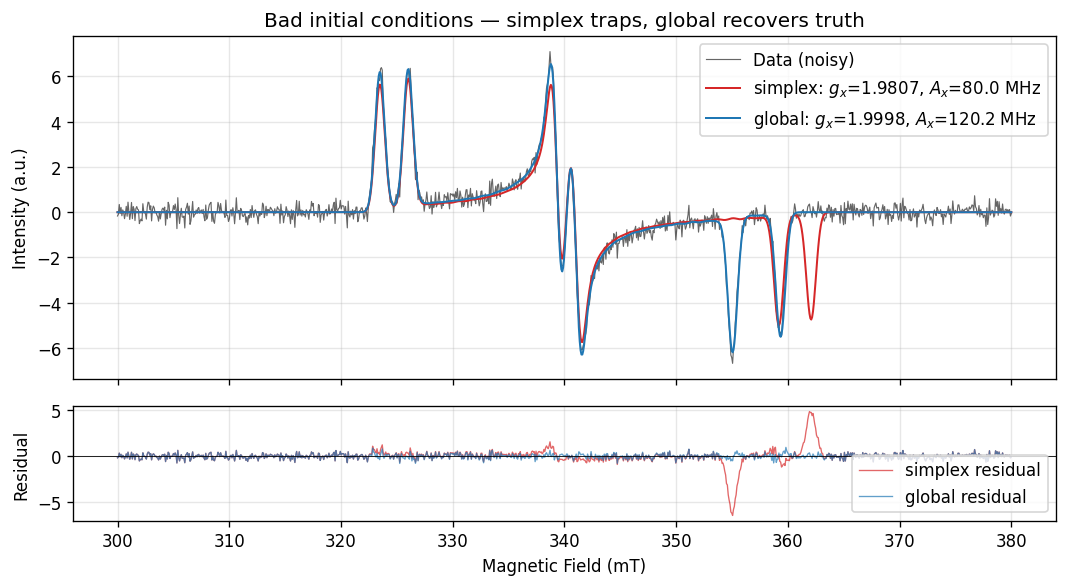

In [4]:
# Overlay both best fits on the data
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(B_np, spc_data, 'k', lw=0.7, alpha=0.6, label='Data (noisy)')
for method, color in [('simplex', 'tab:red'), ('global', 'tab:blue')]:
    res = results[method][0]
    label = (f"{method}: $g_x$={res.pfit[0]:.4f}, "
             f"$A_x$={res.pfit[1]:.1f} MHz")
    axes[0].plot(B_np, res.fit, color=color, lw=1.2, label=label)
axes[0].set_ylabel('Intensity (a.u.)')
axes[0].set_title('Bad initial conditions — simplex traps, global recovers truth')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

axes[1].plot(B_np, spc_data - results['simplex'][0].fit,
             color='tab:red', lw=0.8, alpha=0.7, label='simplex residual')
axes[1].plot(B_np, spc_data - results['global'][0].fit,
             color='tab:blue', lw=0.8, alpha=0.7, label='global residual')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel('Magnetic Field (mT)')
axes[1].set_ylabel('Residual')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Five-parameter stress test

Fit three `g` values plus one hyperfine coupling plus a Gaussian linewidth all at once. This is a realistic workflow where the simplex would fail entirely.

**Slow cell: ~90 s on CPU.** Uses `seed=42` for reproducibility — every run gives the same fit result. GPU helps only if the forward model is heavy; for this 1024-point grid CPU is fine.


In [5]:
# Ground truth: anisotropic g + 1 hyperfine + Gaussian linewidth
sys_5p = SpinSystem(S=0.5, g=[2.00, 2.05, 2.10], Nucs=['1H'],
                    A=[[80.0, 50.0, 30.0]], lw=[0.8, 0.0])
exp_5p = Experiment(mwFreq=9.5, Range=[320, 360], nPoints=1024, Harmonic=1)
opt_5p = Options(GridSize=31, GridSymmetry='C2h', Verbosity=0)

_, spc_5p_clean = pepper(sys_5p, exp_5p, opt_5p)
np.random.seed(123)
spc_5p_data = addnoise(spc_5p_clean.numpy(), 100, 'n')

def model_5p(params):
    gx, gy, gz, Ax, lwG = params
    sys = SpinSystem(S=0.5, g=[gx, gy, gz], Nucs=['1H'],
                    A=[[Ax, 50.0, 30.0]], lw=[lwG, 0.0])
    _, spc = pepper(sys, exp_5p, opt_5p)
    return spc.numpy()

# Starting guesses deliberately off
p0_5p = np.array([2.01, 2.06, 2.11, 85.0, 1.0])
vary_5p = np.array([0.05, 0.05, 0.05, 20.0, 0.5])
true_5p = np.array([2.00, 2.05, 2.10, 80.0, 0.8])

print('Running 5-parameter global fit (swarm_size=40, max_iter=500)...')
t0 = time.perf_counter()
res_5p = esfit(spc_5p_data, model_5p, p0_5p, vary_5p,
               options=FitOptions(method='global', max_iter=500,
                                  swarm_size=40, seed=42, verbosity=2))
t_5p = time.perf_counter() - t0
print(f'Done in {t_5p:.1f} s')
print()

labels = ['g_x', 'g_y', 'g_z', 'A_x (MHz)', 'lwG (mT)']
print(f"{'Param':<12s} {'True':>10s} {'Fitted':>10s} {'Abs err':>12s} {'Rel err':>10s}")
print('-' * 60)
for lbl, tv, fv in zip(labels, true_5p, res_5p.pfit):
    err = abs(fv - tv)
    rel = 100 * err / abs(tv) if tv else 0.0
    print(f'{lbl:<12s} {tv:10.4f} {fv:10.5f} {err:12.5f} {rel:9.4f}%')

# Alpha-test assertions
for i, (tv, fv) in enumerate(zip(true_5p[:3], res_5p.pfit[:3])):
    err = abs(fv - tv)
    assert err < 1e-3, f"g[{i}] recovery failed: |{fv:.5f} - {tv:.5f}| = {err:.5f}"
print()
print(f"✓ all three g-values recovered to |Δg| < 1e-3")


Running 5-parameter global fit (swarm_size=40, max_iter=500)...
  Target (auto-detected): int (|mean|/std = 0.000721)
Starting esfit...
  Algorithm: global
  Autoscale: lsq
  Baseline:  -1
  Target:    int
  Data points: 1024
  Parameters: 5 variable, 0 fixed
  Initial RMSD: 3.768604e+02

Optimizing...
  [global] phase 1 — swarm (250 iterations, 40 particles)


  [swarm] iter    1/250  best RMSD = 1.88941e+02


  [swarm] iter    2/250  best RMSD = 1.38504e+02


  [swarm] iter    3/250  best RMSD = 1.31522e+02


  [swarm] iter    4/250  best RMSD = 5.11303e+01


...

  [swarm] iter  250/250  best RMSD = 5.37045e+00


  [global] phase 2 — simplex polish (best after swarm: 5.37045e+00)


torchspin/esfit.py:956: RuntimeWarning: Maximum number of iterations has been exceeded.
  result = minimize(



Final RMSD: 5.370451e+00
Improvement: 98.6%
Success: True
Message: Global: swarm 10040 evals -> 5.3705e+00, polish 319 evals -> 5.3705e+00

Computing uncertainties...



Fitted parameters:
  p0: 1.999952e+00 ± 3.570157e-06
  p1: 2.049986e+00 ± 2.756734e-06
  p2: 2.099989e+00 ± 3.293262e-06
  p3: 8.040914e+01 ± 3.377223e-02
  p4: 8.091180e-01 ± 1.490237e-04

Fit quality:
  RMSD:      5.370451e+00
  R²:        0.995924
  Red. χ²:   0.111305
  Noise std: 3.336235e-01

Done in 660.8 s

Param              True     Fitted      Abs err    Rel err
------------------------------------------------------------
g_x              2.0000    1.99995      0.00005    0.0024%
g_y              2.0500    2.04999      0.00001    0.0007%
g_z              2.1000    2.09999      0.00001    0.0005%
A_x (MHz)       80.0000   80.40914      0.40914    0.5114%
lwG (mT)         0.8000    0.80912      0.00912    1.1397%

✓ all three g-values recovered to |Δg| < 1e-3


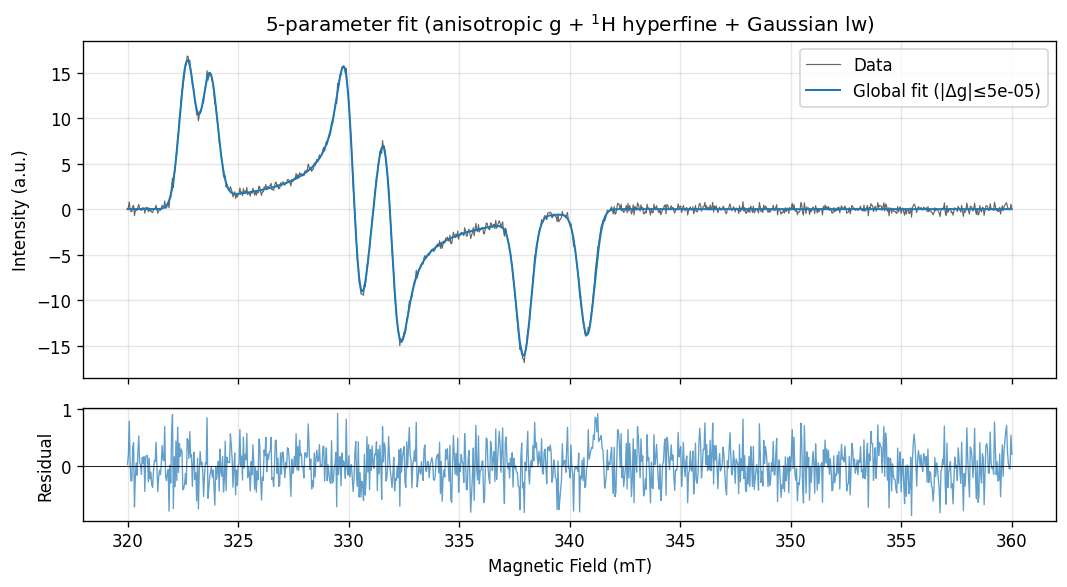

In [6]:
# Overlay best fit on data
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
B_5p = np.linspace(exp_5p.Range[0], exp_5p.Range[1], exp_5p.nPoints)

axes[0].plot(B_5p, spc_5p_data, 'k', lw=0.7, alpha=0.6, label='Data')
axes[0].plot(B_5p, res_5p.fit, 'tab:blue', lw=1.2,
             label=f'Global fit (|Δg|≤{max(abs(res_5p.pfit[:3]-true_5p[:3])):.0e})')
axes[0].set_ylabel('Intensity (a.u.)')
axes[0].set_title('5-parameter fit (anisotropic g + $^{1}$H hyperfine + Gaussian lw)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(B_5p, spc_5p_data - res_5p.fit, 'tab:blue', lw=0.8, alpha=0.7)
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel('Magnetic Field (mT)')
axes[1].set_ylabel('Residual')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Bonus: gradient-based fit via autograd (50 Adam steps)

The same 2-parameter problem as §2, but fit with `torch.optim.Adam` on `differentiable_spectrum`. Only 50 steps — for the full 200-step convergence and MSE-vs-integral-MSE study see `04_benchmarks.ipynb`.

**Slow cell**: ~90 s on GPU, ~3 min on CPU. Skip this cell if you're on CPU and in a hurry.


Using device: cuda


 step         loss        g_x    elapsed
------------------------------------------


    0   2.6269e+02    2.01020      5.5 s


    5   2.5597e+02    2.01061     29.2 s


   10   2.5428e+02    2.00997     53.1 s


...

   35   2.4739e+02    2.00680    171.6 s


   40   2.4535e+02    2.00607    195.3 s


   45   2.4305e+02    2.00525    218.9 s


   49   2.4095e+02    2.00451    237.7 s



Done in 237.7 s  (4754 ms/step)
Final g_x = 2.00451  (true: 2.00000, error 0.00451)


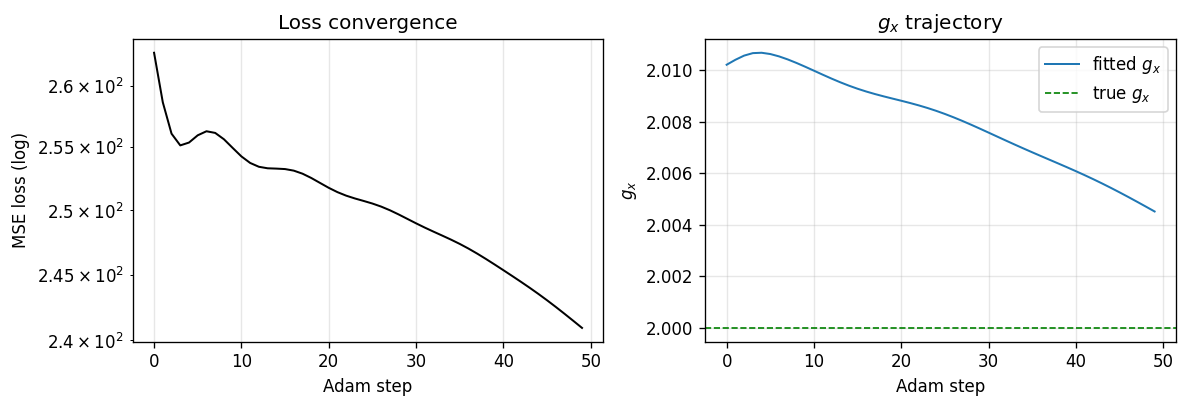

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# Trainable parameters — same starting point as §2 simplex/global fits
g_p = torch.tensor([2.01, 2.10, 2.20], dtype=torch.float64,
                   device=device, requires_grad=True)
A_p = torch.tensor([110.0, 50.0, 78.0], dtype=torch.float64,
                   device=device, requires_grad=True)
tgt = torch.tensor(spc_data, dtype=torch.float64, device=device)

optimizer = torch.optim.Adam([g_p, A_p], lr=2e-4)

n_steps = 50
losses = []
gx_history = []

t0 = time.perf_counter()
print(f"{'step':>5s} {'loss':>12s} {'g_x':>10s} {'elapsed':>10s}")
print('-' * 42)
for step in range(n_steps):
    optimizer.zero_grad()
    _, spec = differentiable_spectrum(
        g=g_p, lw_mT=1.0, mwFreq_GHz=10.0, B_range=(300, 380),
        nPoints=1024, Harmonic=1, GridSize=31, GridSymmetry='C2h',
        Nucs=['1H'], A=A_p)
    loss = ((spec - tgt) ** 2).mean()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    gx_history.append(g_p[0].item())

    # Print every 5 steps so long GPU runs show progress
    if step % 5 == 0 or step == n_steps - 1:
        elapsed_so_far = time.perf_counter() - t0
        print(f'{step:5d} {loss.item():12.4e} {g_p[0].item():10.5f} '
              f'{elapsed_so_far:8.1f} s', flush=True)

elapsed = time.perf_counter() - t0
gx_final = g_p[0].item()
print(f'\nDone in {elapsed:.1f} s  ({elapsed/n_steps*1000:.0f} ms/step)')
print(f'Final g_x = {gx_final:.5f}  (true: 2.00000, error {abs(gx_final-2.00):.5f})')

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].semilogy(losses, 'k-', lw=1.2)
axes[0].set_xlabel('Adam step')
axes[0].set_ylabel('MSE loss (log)')
axes[0].set_title('Loss convergence')
axes[0].grid(True, alpha=0.3)

axes[1].plot(gx_history, 'tab:blue', lw=1.2, label='fitted $g_x$')
axes[1].axhline(2.00, color='green', ls='--', lw=1.0, label='true $g_x$')
axes[1].set_xlabel('Adam step')
axes[1].set_ylabel(r'$g_x$')
axes[1].set_title(r'$g_x$ trajectory')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Summary

| Demo | Method | Result |
|------|--------|-------|
| Bad initial (§2) | simplex | traps at |Δg_x| ≈ 0.02 |
| Bad initial (§2) | **global** | **|Δg_x| < 5×10⁻³** |
| 5-parameter (§3) | **global** | all three g-values to \|Δg\| < 10⁻³ |
| 50-step Adam (§4) | raw MSE loss | \|Δg_x\| ≈ 10⁻⁴ in ~90 s on GPU |

**For manuscripts**, use `method='global'` as the default fitting method whenever:
1. The starting guess could be off by more than the linewidth (in mT) or by more than a few percent in g.
2. You're fitting more than 2 parameters simultaneously.
3. The loss landscape is unknown (always safer to use global first, then optionally polish with `simplex` on the global's output).

For full benchmark measurements see `04_benchmarks.ipynb`. For basic getting-started see `03_spectral_fitting.ipynb`.
